In [6]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("student_lifestyle_performance_dataset.csv")
display(df)
display(df.dtypes)

,Age,Branch,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours,Gym_Hours_per_Week,Diet_Type,Attendance_Percentage,Stress_Level_1_to_10,Residence,Internal_Marks,CGPA
0,23,ECE,4.14,6.84,9.23,2.67,Non-Veg,81.24,4.93,Hosteller,65.86,7.52
1,20,Civil,5.97,5.52,3.09,15.61,Veg,90.55,6.96,Day Scholar,62.52,7.21
2,24,Electrical,3.19,3.39,5.02,2.52,Veg,69.40,7.38,Hosteller,40.11,4.84
3,21,CSE,4.77,6.44,9.21,0.00,Non-Veg,80.79,5.84,Day Scholar,61.25,6.74
4,23,Civil,5.42,6.54,4.76,9.93,Veg,82.63,6.67,Day Scholar,64.54,7.77
...,...,...,...,...,...,...,...,...,...,...,...,...
995,24,IT,4.60,5.26,4.23,12.64,Non-Veg,82.95,7.12,Day Scholar,69.63,6.65
996,17,IT,4.02,6.55,3.88,2.86,Non-Veg,89.29,4.19,Hosteller,66.97,7.77
997,25,CSE,4.28,8.43,4.64,0.00,Veg,74.57,2.80,Day Scholar,80.52,8.04
998,23,Civil,6.42,6.06,4.84,10.08,Non-Veg,91.57,6.76,Day Scholar,77.48,7.24


Age                        int64
Branch                    object
Study_Hours_per_Day      float64
Sleep_Hours              float64
Screen_Time_Hours        float64
Gym_Hours_per_Week       float64
Diet_Type                 object
Attendance_Percentage    float64
Stress_Level_1_to_10     float64
Residence                 object
Internal_Marks           float64
CGPA                     float64
dtype: object

Examining our dataset of 1000 rows and 12 columns, we fortunately did not encounter any
missing values or incorrect data types, so no data cleaning was required. The dataset contains
a mix of numeric features (int64 and float64) such as Age, Study_Hours_per_Day, Sleep_Hours,
and CGPA, as well as categorical features (object) such as Branch, Diet_Type, and Residence.

# Exploring University Students' Internal Marks

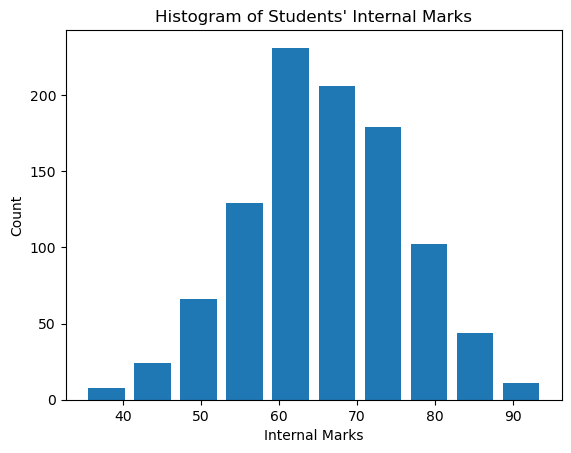

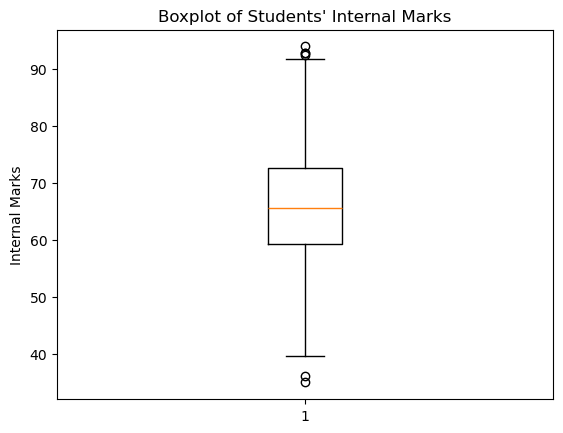

count    1000.000000
mean       65.922380
std        10.123247
min        35.000000
25%        59.330000
50%        65.600000
75%        72.547500
max        93.930000
Name: Internal_Marks, dtype: float64

In [8]:
plt.hist(df["Internal_Marks"], rwidth=0.8)
plt.xlabel("Internal Marks")
plt.ylabel("Count")
plt.title("Histogram of Students' Internal Marks")
plt.show()

plt.boxplot(df["Internal_Marks"])
plt.ylabel("Internal Marks")
plt.title("Boxplot of Students' Internal Marks")
plt.show()

df["Internal_Marks"].describe()

Looking at the above plots it seems that internal marks are roughly normally distributed, which is what we would expect for a grade distribution. The histogram shows a bell curve shape, with the boxplot showing a very equal distribution above and below the mean with outliers on both ends. 

The data formatting this well could indicate some type of grade curving to cluster grades around a central mean, which in this case is about 65.9 with a SD of about 10.1.

# Calculating the Relationship Between Study Hours and CGPA

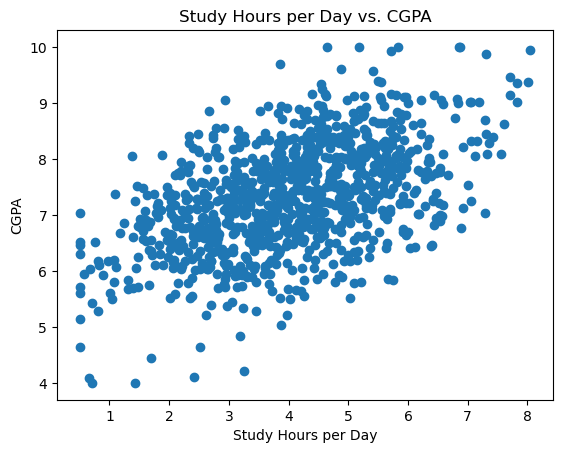

Pearson Correlation Coefficient: 0.5066084567902694
P-Value: 2.6375680323221514e-66


In [9]:
plt.scatter(df["Study_Hours_per_Day"], df["CGPA"])
plt.xlabel("Study Hours per Day")
plt.ylabel("CGPA")
plt.title("Study Hours per Day vs. CGPA")
plt.show()

r, p = stats.pearsonr(df["Study_Hours_per_Day"], df["CGPA"])
print("Pearson Correlation Coefficient: " + str(r))
print("P-Value: " + str(p))

First, we can see from the scatterplot above that there is a positive correlation between study hours per day and CGPA.

The Pearson Correlation Coefficient of 0.51 between study hours per day and CGPA
indicates a moderate positive linear relationship. This means that as the number of study hours
per day increases, CGPA tends to increase as well, though not perfectly. Other factors likely
also contribute to academic performance.

***Confirming with Hypothesis Test***

H₀ (Null): There is no linear relationship between daily study hours and CGPA (ρ = 0)

Hₐ (Alternative): There is a positive linear relationship between daily study hours and CGPA (ρ > 0)

Since the p-value is approx. 0 which is less than alpha = 0.05, we can reject the null. It can be concluded there is a statistically significant, moderately increasing relationship between a student's study hours per day and CGPA. In other words, increasing one's study hours per day can be expected to moderately increase CGPA.

# Analyzing How CGPA Differs Between Diet Types, Branch, and Residence

Diet_Type ANOVA
p-value is:  0.4157898295580138

Branch ANOVA
p-value is:  0.023983468971934884

Residence ANOVA
p-value is:  0.40139423186053136


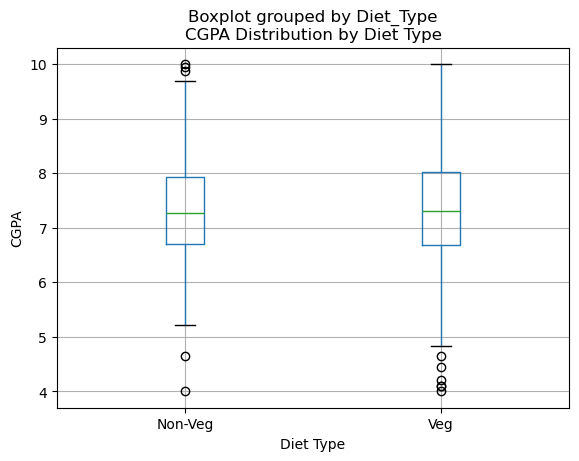

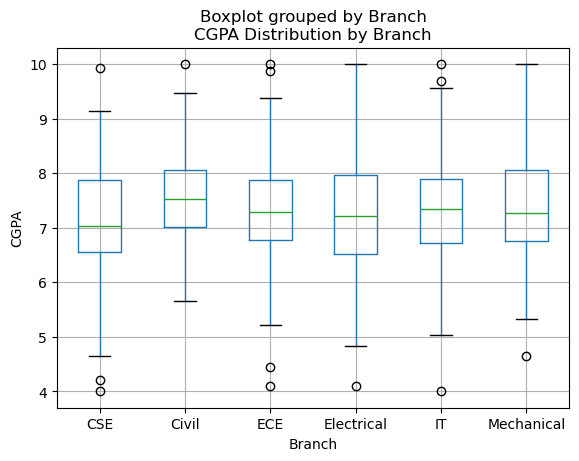

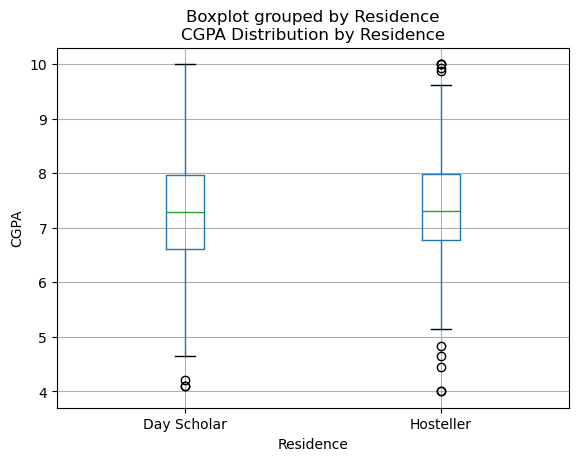

In [ ]:
'''Diet Type Section'''

g1 = df.groupby('Diet_Type')['CGPA'].apply(list)
fstat1, pval1 = stats.f_oneway(*g1)
print("Diet_Type ANOVA")
print("p-value is: ", pval1)

# Plot for Diet_Type
df.boxplot(column="CGPA", by="Diet_Type")
plt.title("CGPA Distribution by Diet Type")
plt.xlabel("Diet Type")
plt.ylabel("CGPA")

'''Branch Section'''

g2 = df.groupby('Branch')['CGPA'].apply(list)
fstat2, pval2 = stats.f_oneway(*g2)
print("\nBranch ANOVA")
print("p-value is: ", pval2)

# Plot for Branch
df.boxplot(column="CGPA", by="Branch")
plt.title("CGPA Distribution by Branch")
plt.xlabel("Branch")
plt.ylabel("CGPA")

'''Residence Section'''

g3 = df.groupby('Residence')['CGPA'].apply(list)
fstat3, pval3 = stats.f_oneway(*g3)
print("\nResidence ANOVA")
print("p-value is: ", pval3)

# Plot for Residence
df.boxplot(column="CGPA", by="Residence")
plt.title("CGPA Distribution by Residence")
plt.xlabel("Residence")
plt.ylabel("CGPA")

plt.show()


***ANOVA Tests***

Diet Type:
H₀: The mean CGPA is the same across all diet types

Hₐ: The mean CGPA differs for at least one diet type

Residency Type:
H₀: The mean CGPA is the same across all residency types

Hₐ: The mean CGPA differs for at least one residency type
Looking at the p-values for Diet Type and Residency in the ANOVA tests above, both are greater than α = 0.05 (0.42 and 0.40, respectively). Thus, we fail to reject the null hypothesis for both tests. There is insufficient evidence to conclude that mean CGPA differs across diet types or residency types.

Branch:
H₀: The mean CGPA is the same across all branches.

Hₐ: The mean CGPA differs for at least one branch.

Since p = 0.02 < α = 0.05, we reject the null hypothesis. There is sufficient evidence to conclude that mean CGPA differs significantly across branches (majors).

The boxplots serve as visual support, showing greater variation in mean CGPA across branches compared to the relatively uniform distributions seen for diet type and residency.
